# LSTM Model for Heat Risk Prediction

This notebook implements LSTM models for both regression (forecast apparent temperature) and classification (predict heat risk) tasks.

## Tasks:
1. Load train/validation/test splits
2. TODO: Prepare sequential data (create time windows/sequences)
3. TODO: Feature selection and scaling
4. TODO: Build LSTM architecture for regression (forecast `heat_index_next_day` - apparent temperature)
5. TODO: Train regression model
6. TODO: Hyperparameter tuning
7. TODO: Make predictions
8. TODO: Build classification model (predict `heat_risk` - binary classification based on temperature conditions)
9. TODO: Evaluate models
10. TODO: Save models

**Note**: Heat risk is typically derived from apparent temperature thresholds (e.g., >90°F = high risk). The regression task forecasts the continuous temperature value, while the classification task predicts the binary risk category. LSTM sequences predict the next day's temperature, then classify risk.


## Step 1: Mount Google Drive and Set Up Environment


In [1]:
# Mount Google Drive and set repo path (Colab)
import os
from pathlib import Path

repo_path = '/content/drive/MyDrive/SHADE-ML-Team'
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    if not os.path.exists(repo_path):
        os.makedirs('/content/drive/MyDrive', exist_ok=True)
        # Optionally clone if missing:
        # !git clone https://github.com/HrudithL/SHADE-ML-Team.git /content/drive/MyDrive/SHADE-ML-Team
    os.chdir(repo_path)
    print(f"Using repo at: {os.getcwd()}")
except ImportError:
    # Running locally - set directory to project root
    current_dir = Path(os.getcwd())
    # If we're in a subdirectory (like notebooks), go up to project root
    if current_dir.name == 'notebooks':
        project_root = current_dir.parent
    else:
        # Try to find project root by looking for common markers
        project_root = current_dir
        # Look for .git directory or go up until we find it
        while project_root != project_root.parent:
            if (project_root / '.git').exists() or (project_root / 'README.md').exists():
                break
            project_root = project_root.parent
    
    os.chdir(project_root)
    print(f"Running locally; set CWD to project root: {os.getcwd()}")
    

Running locally; set CWD to project root: c:\Users\hrudi\OneDrive\Documents\TAMU\SHADE\ML-Repo


In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf

# Access Keras components through tf.keras (avoids IDE import resolution issues)
# This approach works at runtime and prevents static analysis errors
Sequential = tf.keras.models.Sequential
load_model = tf.keras.models.load_model
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
BatchNormalization = tf.keras.layers.BatchNormalization
Adam = tf.keras.optimizers.Adam
EarlyStopping = tf.keras.callbacks.EarlyStopping
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


Libraries imported successfully!
TensorFlow version: 2.20.0
GPU Available: []


## Step 2: GPU Setup Instructions

**Important**: For LSTM training, use GPU runtime for faster training.

1. Click **Runtime** → **Change runtime type**
2. Select **GPU** as Hardware accelerator
3. Click **Save**
4. Re-run all cells after switching to GPU

**Verify GPU is available** (should show above if GPU is selected)


In [ ]:
# Verify GPU setup
if tf.config.list_physical_devices('GPU'):
    print("✓ GPU is available!")
    print(f"GPU Device: {tf.config.list_physical_devices('GPU')[0].name}")
else:
    print("⚠ GPU not available. Consider switching to GPU runtime for faster training.")


⚠ GPU not available. Consider switching to GPU runtime for faster training.


## Step 3: Load Data Splits


In [7]:
# Load train/validation/test splits
train_data = pd.read_csv('data/processed/train_data.csv')
val_data = pd.read_csv('data/processed/validation_data.csv')
test_data = pd.read_csv('data/processed/test_data.csv')

# Convert Date to datetime
train_data['Date'] = pd.to_datetime(train_data['Date'])
val_data['Date'] = pd.to_datetime(val_data['Date'])
test_data['Date'] = pd.to_datetime(test_data['Date'])

print("✓ Data loaded successfully!")
print(f"Train shape: {train_data.shape}")
print(f"Validation shape: {val_data.shape}")
print(f"Test shape: {test_data.shape}")

print(f"\nTrain date range: {train_data['Date'].min()} to {train_data['Date'].max()}")
print(f"Validation date range: {val_data['Date'].min()} to {val_data['Date'].max()}")
print(f"Test date range: {test_data['Date'].min()} to {test_data['Date'].max()}")
train_data.head()

✓ Data loaded successfully!
Train shape: (7248, 32)
Validation shape: (1553, 32)
Test shape: (1553, 32)

Train date range: 1999-01-01 00:00:00 to 2016-05-28 00:00:00
Validation date range: 2016-05-29 00:00:00 to 2019-06-26 00:00:00
Test date range: 2019-06-27 00:00:00 to 2023-09-26 00:00:00


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events,...,PrevDayTemp,PrevDayHumidity,TempAvg_7day,HumidityAvg_7day,HeatIndex,heat_index_high,temp_percentile_high,heat_risk_day,heat_risk,heat_index_next_day
0,1999-01-01,73.9,51.8,60.5,57.9,92.0,1008.7,4.2,0.0,NaN,...,NaN,NaN,60.500,92.000000,60.5740,0,0,0,0,45.1687
1,1999-01-02,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,NaN,...,60.5,92.0,54.350,72.050000,45.1687,0,0,0,0,30.6930
2,1999-01-03,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,NaN,...,48.2,52.1,48.100,61.033333,30.6930,0,0,0,0,29.3739
3,1999-01-04,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,NaN,...,35.6,39.0,44.625,56.700000,29.3739,0,0,0,0,36.7822
4,1999-01-05,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,NaN,...,34.2,43.7,43.640,59.880000,36.7822,0,0,0,0,53.6910






## Step 4: Prepare Sequential Data

Create sequences for LSTM input. **TODO**: Select features, scale data, and create time windows/sequences for both regression (forecast apparent temperature) and classification (predict heat risk) tasks.


In [8]:
# TODO: PREPARE SEQUENTIAL DATA FOR LSTM
# Create time windows/sequences for both regression and classification tasks
# LSTM requires sequences where each sample uses previous N days to predict next day

print("=" * 80)
print("PREPARING SEQUENTIAL DATA")
print("=" * 80)

# TODO: Select features for LSTM
# Choose relevant features for time-series prediction
# Consider: temperature, humidity, pressure, time-based features, etc.
feature_cols = [
    'TempHighF', 'TempLowF', 'TempAvgF',
    'HumidityAvgPercent', 'DewPointAvgF',
    'sealevelpressure', 'VisibilityAvgMiles',
    'PrecipitationSumInches',
    'PrevDayTemp', 'PrevDayHumidity',
    'TempAvg_7day', 'HumidityAvg_7day',
    'DailyTempRange', 'TempPressure',
    'HeatIndex',
    'DayOfYear',
]


# --- FIX: Drop NaN rows before scaling or sequence creation ---
# Remove rows where target or feature values are missing

train_data = train_data.dropna(subset=feature_cols + ['heat_index_next_day'])
val_data   = val_data.dropna(subset=feature_cols + ['heat_index_next_day'])
test_data  = test_data.dropna(subset=feature_cols + ['heat_index_next_day'])

print("NaNs removed. New shapes:")
print("Train:", train_data.shape)
print("Val:", val_data.shape)
print("Test:", test_data.shape)


# TODO: Scale features
# Use MinMaxScaler or StandardScaler to normalize features
scaler = MinMaxScaler()  # TODO: Choose scaler type
train_scaled = scaler.fit_transform(train_data[feature_cols])
val_scaled = scaler.transform(val_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# TODO: Set lookback window
# Choose appropriate lookback window (e.g., 7, 14, 30, 60 days)
# This determines how many previous days to use to predict the next day
lookback = 14  # TODO: Set value (e.g., 30)
n_features = len(feature_cols)

# TODO: Create sequence creation function
# Function should create sequences where each sample uses previous N days
# Input: scaled data, lookback window, target data
# Output: X (sequences) and y (targets)
def create_sequences(data, lookback, target_data=None):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])  # Previous N days
        if target_data is not None:
            y.append(target_data[i])  # Next day's target
    return np.array(X), np.array(y)

# TODO: Create sequences for regression
# Target: heat_index_next_day (apparent temperature - continuous value)
X_train_reg, y_train_reg = create_sequences(train_scaled, lookback,
                                              target_data=train_data['heat_index_next_day'].values)
X_val_reg, y_val_reg = create_sequences(val_scaled, lookback,
                                         target_data=val_data['heat_index_next_day'].values)
X_test_reg, y_test_reg = create_sequences(test_scaled, lookback,
                                          target_data=test_data['heat_index_next_day'].values)

# TODO: Create sequences for classification
# Target: heat_risk (binary classification based on temperature conditions)
X_train_cls, y_train_cls = create_sequences(train_scaled, lookback,
                                              target_data=train_data['heat_risk'].values)
X_val_cls, y_val_cls = create_sequences(val_scaled, lookback,
                                         target_data=val_data['heat_risk'].values)
X_test_cls, y_test_cls = create_sequences(test_scaled, lookback,
                                           target_data=test_data['heat_risk'].values)

# TODO: Verify sequence shapes
# X should be (samples, time_steps, features) = (samples, lookback, n_features)
# y should be (samples,)
print(f"Regression sequences shape: {X_train_reg.shape}")
print(f"Regression target shape: {y_train_reg.shape}")
print(f"Classification sequences shape: {X_train_cls.shape}")
print(f"Classification target shape: {y_train_cls.shape}")


PREPARING SEQUENTIAL DATA
NaNs removed. New shapes:
Train: (7247, 32)
Val: (1553, 32)
Test: (1552, 32)
Regression sequences shape: (7233, 14, 16)
Regression target shape: (7233,)
Classification sequences shape: (7233, 14, 16)
Classification target shape: (7233,)


## Step 5: Build LSTM Architecture for Regression

Build LSTM architecture for regression. **TODO**: Design and compile the model. **Target**: Forecast `heat_index_next_day` (apparent temperature - continuous value prediction). Output: 1 neuron with linear activation.


In [9]:
# TODO: BUILD LSTM ARCHITECTURE FOR REGRESSION
# Design and build LSTM model for forecasting apparent temperature
# Target: heat_index_next_day (continuous value)

print("=" * 80)
print("BUILDING LSTM REGRESSION MODEL")
print("=" * 80)

# TODO: Set LSTM hyperparameters
# Research appropriate values for time-series regression
# Consider:
#   - Number of LSTM units (e.g., 50, 100, 200)
#   - Number of LSTM layers (1-3)
#   - Dropout rate (0.2-0.5)
#   - Dense layer units
#   - Learning rate
lstm_units_1 = 32  # TODO: Set value (e.g., 50, 100)
lstm_units_2 = 32  # TODO: Set value (e.g., 50, 100) or None if single layer
dropout_rate = 0.3  # TODO: Set value (e.g., 0.2, 0.3, 0.5)
dense_units = 50   # TODO: Set value (e.g., 25, 50)
learning_rate = 0.001 # TODO: Set value (e.g., 0.001, 0.01, 0.0001)

# TODO: Build LSTM model architecture
# Use Sequential model with:
#   - Input layer: accepts sequences of shape (lookback, n_features)
#   - LSTM layers: use return_sequences=True for stacked LSTMs
#   - Dropout layers: prevent overfitting
#   - Dense layers: fully connected layers before output
#   - Output layer: 1 neuron with linear activation (for continuous prediction)
# Consider BatchNormalization for stability
model_regression = Sequential([
    LSTM(lstm_units_1, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(dropout_rate),
    LSTM(lstm_units_2, return_sequences=False),  # Only if using 2+ layers
    Dropout(dropout_rate),
    Dense(dense_units),
    Dense(1)  # Output layer for regression (linear activation by default)
])

# TODO: Compile model
# Use Adam optimizer with learning rate
# Loss: 'mse' or 'mae' for regression
# Metrics: ['mae'] or ['mse']
model_regression.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',  # TODO: Consider 'mae' as alternative
    metrics=['mae']
)

# TODO: Display model summary
model_regression.summary()


BUILDING LSTM REGRESSION MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         1,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,293 (63.64 KB)

 Trainable params: 16,293 (63.64 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train Regression Model

Train the LSTM regression model. **TODO**: Set up callbacks and train the model. **Important**: Don't shuffle time-series data (shuffle=False). Monitor validation loss for temperature prediction.


TRAINING LSTM REGRESSION MODEL
Epoch 1/250


227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 71.8479 - mae: 6.6799 - val_loss: 51.9167 - val_mae: 5.4205 - learning_rate: 1.2500e-05
Epoch 2/250
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 73.5143 - mae: 6.7701 - val_loss: 51.9684 - val_mae: 5.4277 - learning_rate: 1.2500e-05
Epoch 3/250
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 72.5985 - mae: 6.7011 - val_loss: 52.0221 - val_mae: 5.4341 - learning_rate: 1.2500e-05
Epoch 4/250
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 70.4993 - mae: 6.6060 - val_loss: 51.9297 - val_mae: 5.4208 - learning_rate: 1.2500e-05
Epoch 5/250
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 71.9417 - mae: 6.6885 - val_loss: 51.7908 - val_mae: 5.3978 - learning_rate: 1.2500e-05
Epoch 6/250
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 73.3058 - mae: 6.7966 - val_loss: 52.3691 - val_mae: 5.4783 - learning_rate: 1.2500e-05
Epoch 7/250
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 73.4413 - mae: 6.7627 - val_loss: 52.1587 - val_mae: 5.45

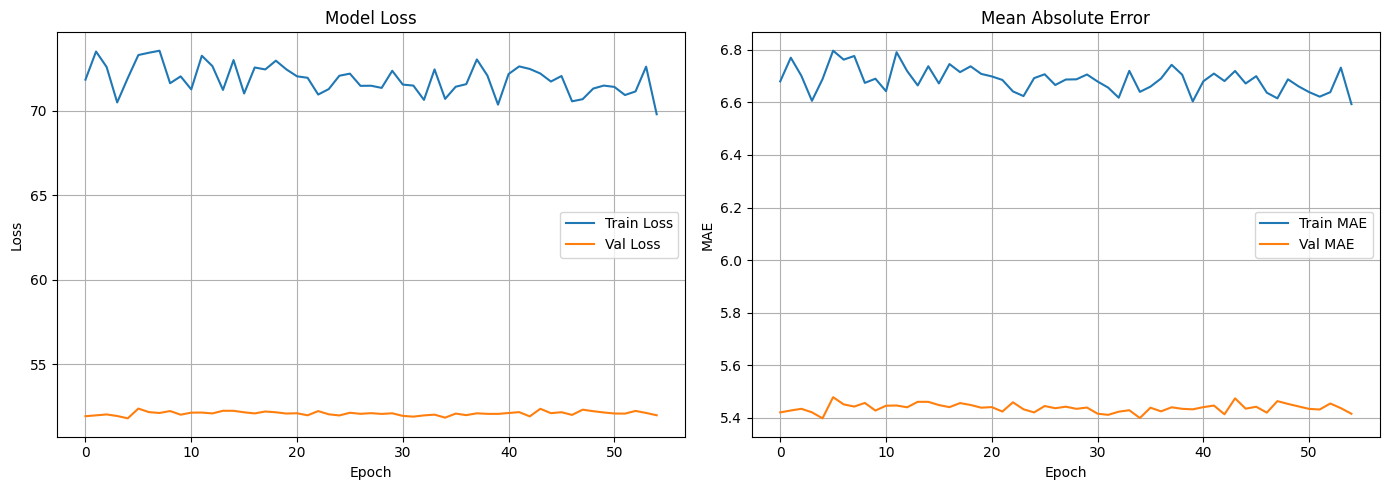

In [14]:
# TODO: TRAIN LSTM REGRESSION MODEL
# Train the model with appropriate callbacks and monitor validation loss

print("=" * 80)
print("TRAINING LSTM REGRESSION MODEL")
print("=" * 80)

# TODO: Set training hyperparameters
batch_size = 32  # TODO: Set value (e.g., 32, 64, 128)
epochs = 250      # TODO: Set value (e.g., 50, 100)

# TODO: Set up callbacks
# EarlyStopping: prevent overfitting, monitor validation loss
# FIXED: Added min_delta to prevent stopping on tiny fluctuations
# FIXED: Increased patience to allow more training before stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,  # Increased from 30 to allow more training
    min_delta=0.001,  # Only stop if improvement is less than 0.001
    restore_best_weights=True,
    verbose=1  # Show when early stopping triggers
)

# ReduceLROnPlateau: adjust learning rate when validation loss plateaus
# FIXED: Increased patience to be less aggressive
# FIXED: Lowered min_lr to allow finer adjustments
# FIXED: Added verbose to see when LR is reduced
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half when plateau detected
    patience=15,  # Increased from 5 to 15 - wait longer before reducing LR
    min_lr=1e-2,  # Lowered from 0.0001 to 1e-6 for finer adjustments
    verbose=1  # Show when learning rate is reduced
)

# TODO: Train the model
# Fit on training sequences, validate on validation sequences
# **CRITICAL**: Set shuffle=False for time-series data!
history_regression = model_regression.fit(
    X_train_reg, y_train_reg,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val_reg, y_val_reg),
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
    shuffle=False  # Don't shuffle time-series data!
)

# TODO: Plot training history
# Visualize training and validation loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_regression.history['loss'], label='Train Loss')
axes[0].plot(history_regression.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
# Similar plot for MAE if included in metrics
axes[1].plot(history_regression.history['mae'], label='Train MAE')
axes[1].plot(history_regression.history['val_mae'], label='Val MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


## Step 7: Hyperparameter Tuning

Experiment with different hyperparameters. **TODO**: Tune lookback window, LSTM units, layers, dropout, learning rate, etc.


In [ ]:
# TODO: HYPERPARAMETER TUNING
# Experiment with different hyperparameters to improve model performance
# FIXED: Now saves checkpoints during tuning and can resume from saved state

import json

# Create output directory for tuning results
os.makedirs('models/lstm', exist_ok=True)

# Define paths for saving tuning results
tuning_model_path = 'models/lstm/best_lstm_regression_tuned.keras'
tuning_config_path = 'models/lstm/best_lstm_config_tuned.json'
tuning_state_path = 'models/lstm/tuning_state.json'

perform_tuning = True  # TODO: Set to True to enable hyperparameter tuning

if perform_tuning:
    print("=" * 80)
    print("HYPERPARAMETER TUNING")
    print("=" * 80)

    # TODO: Define hyperparameters to tune
    # Consider:
    #   - lookback window size (e.g., 7, 14, 30, 60 days)
    #   - LSTM units (e.g., 50, 100, 200)
    #   - Number of LSTM layers (1, 2, 3)
    #   - Dropout rate (e.g., 0.2, 0.3, 0.5)
    #   - Learning rate (e.g., 0.001, 0.01, 0.0001)
    #   - Batch size (e.g., 16, 32, 64)
    #   - Dense layer units
    lstm_units_list1 = [32, 64]
    lstm_units_list2 = [16, 32]
    dropout_list     = [0.2, 0.3, 0.5]
    dense_units_list = [32, 50]
    learning_rates   = [0.001, 0.0005]
    batch_sizes      = [32, 64]

    # Try to load existing tuning state (allows resuming if interrupted)
    best_val_loss = float("inf")
    best_config = None
    best_model = None
    
    if os.path.exists(tuning_config_path):
        print(f"✓ Found existing tuning results at {tuning_config_path}")
        print("Loading previous best configuration...")
        try:
            with open(tuning_config_path, "r") as f:
                best_config = json.load(f)
            best_val_loss = best_config.get("best_val_loss", float("inf"))
            print(f"Previous best val_loss: {best_val_loss:.4f}")
            print(f"Previous best config: {best_config}")
            
            # Try to load the saved model
            if os.path.exists(tuning_model_path):
                try:
                    best_model = load_model(tuning_model_path)
                    print("✓ Loaded previous best model")
                except Exception as e:
                    print(f"⚠ Could not load previous model: {e}")
                    print("Will continue tuning from scratch...")
        except Exception as e:
            print(f"⚠ Could not load previous config: {e}")
            print("Starting tuning from scratch...")

    # TODO: Test different configurations
    # Use validation set to evaluate different configurations
    config_count = 0
    total_configs = (len(lstm_units_list1) * len(lstm_units_list2) * 
                     len(dropout_list) * len(dense_units_list) * 
                     len(learning_rates) * len(batch_sizes))
    
    for lstm_units1 in lstm_units_list1:
        for lstm_units2 in lstm_units_list2:
            if lstm_units1 < lstm_units2:
                continue
            for dropout_rate in dropout_list:
                for dense_units in dense_units_list:
                    for lr in learning_rates:
                        for bs in batch_sizes:
                            config_count += 1
                            print(f"\n[{config_count}/{total_configs}] Testing config:"
                                  f" LSTM1={lstm_units1}, LSTM2={lstm_units2},"
                                  f" Dropout={dropout_rate}, Dense={dense_units},"
                                  f" LR={lr}, Batch={bs}")

                            # Build model for this config
                            model = Sequential([
                                LSTM(lstm_units1, return_sequences=True,
                                     input_shape=(lookback, n_features)),
                                Dropout(dropout_rate),
                                LSTM(lstm_units2, return_sequences=False),
                                Dropout(dropout_rate),
                                Dense(dense_units),
                                Dense(1)
                            ])

                            model.compile(
                                optimizer=Adam(learning_rate=lr),
                                loss="mse",
                                metrics=["mae"]
                            )

                            # Train the model
                            early_stop = EarlyStopping(
                                monitor='val_loss', 
                                patience=5, 
                                restore_best_weights=True,
                                verbose=0
                            )
                            reduce_learn = ReduceLROnPlateau(
                                monitor='val_loss',
                                factor=0.5,
                                patience=3,
                                min_lr=1e-5,
                                verbose=0
                            )
                            history = model.fit(
                                X_train_reg, y_train_reg,
                                validation_data=(X_val_reg, y_val_reg),
                                epochs=60,        # fewer epochs for searching
                                batch_size=bs,
                                verbose=0,
                                shuffle=False,
                                callbacks=[early_stop, reduce_learn]
                            )

                            val_loss = min(history.history["val_loss"])
                            print(f" → Best val_loss: {val_loss:.4f}")
                            
                            # Track best model and save immediately if it's better
                            if val_loss < best_val_loss:
                                best_val_loss = val_loss
                                best_config = {
                                    "lstm_units1": lstm_units1,
                                    "lstm_units2": lstm_units2,
                                    "dropout": dropout_rate,
                                    "dense_units": dense_units,
                                    "learning_rate": lr,
                                    "batch_size": bs,
                                    "best_val_loss": best_val_loss
                                }
                                best_model = model
                                
                                # Save immediately after finding better model
                                print(f"  ✓ New best model! Saving to {tuning_model_path}")
                                try:
                                    best_model.save(tuning_model_path)
                                    with open(tuning_config_path, "w") as f:
                                        json.dump(best_config, f, indent=2)
                                    print(f"  ✓ Saved best config to {tuning_config_path}")
                                except Exception as e:
                                    print(f"  ⚠ Error saving model: {e}")
                            
                            print(f"  Best so far: val_loss={best_val_loss:.4f}")

    # Final save and summary
    if best_model is not None:
        model_regression = best_model
        print("\n" + "=" * 80)
        print("HYPERPARAMETER TUNING COMPLETE")
        print("=" * 80)
        print("Best configuration selected:")
        print(json.dumps(best_config, indent=2))
        print(f"\nBest validation loss: {best_val_loss:.4f}")
        print(f"\n✓ Best model saved to: {tuning_model_path}")
        print(f"✓ Best config saved to: {tuning_config_path}")
    else:
        print("\n⚠ No model was trained during tuning!")

else:
    print("=" * 80)
    print("SKIPPING HYPERPARAMETER TUNING")
    print("=" * 80)
    print("Set perform_tuning = True to enable hyperparameter tuning")

    # Try loading best previously tuned model
    if os.path.exists(tuning_model_path) and os.path.exists(tuning_config_path):
        print(f"\n✓ Found previously tuned model at {tuning_model_path}")
        print("Loading best model and config...")

        try:
            model_regression = load_model(tuning_model_path)
            
            with open(tuning_config_path, "r") as f:
                best_config = json.load(f)

            print("✓ Successfully loaded tuned model!")
            print("\nUsing best previously tuned model with hyperparameters:")
            print(json.dumps(best_config, indent=2))
        except Exception as e:
            print(f"⚠ Error loading tuned model: {e}")
            print("Will use default regression model instead.")
            best_config = None
    else:
        print(f"\n⚠ No tuned model found at {tuning_model_path}")
        print("Using default regression model instead.")
        best_config = None



HYPERPARAMETER TUNING

Testing config: LSTM1=32 LSTM2=16, Dropout=0.2, Dense=32, LR=0.001, Batch=32
 → Best val_loss: 51.6877
Best model so far: {'lstm_units1': 32, 'lstm_units2': 16, 'dropout': 0.2, 'dense_units': 32, 'learning_rate': 0.001, 'batch_size': 32} with val_loss: 51.68766784667969

Testing config: LSTM1=32 LSTM2=16, Dropout=0.2, Dense=32, LR=0.001, Batch=64
 → Best val_loss: 52.7567
Best model so far: {'lstm_units1': 32, 'lstm_units2': 16, 'dropout': 0.2, 'dense_units': 32, 'learning_rate': 0.001, 'batch_size': 32} with val_loss: 51.68766784667969

Testing config: LSTM1=32 LSTM2=16, Dropout=0.2, Dense=32, LR=0.0005, Batch=32


KeyboardInterrupt: 

## Step 8: Make Predictions and Evaluate Regression Model

Make predictions and evaluate regression performance. **TODO**: Predict, calculate metrics (RMSE, MAE, R²), and visualize results for temperature forecasting.


In [ ]:
# TODO: MAKE PREDICTIONS AND EVALUATE REGRESSION MODEL
# Predict and evaluate temperature forecasting performance

print("=" * 80)
print("REGRESSION MODEL EVALUATION")
print("=" * 80)

# TODO: Make predictions
# Predict on train, validation, and test sets

y_train_pred_reg = model_regression.predict(X_train_reg, verbose=0)
y_val_pred_reg = model_regression.predict(X_val_reg, verbose=0)
y_test_pred_reg = model_regression.predict(X_test_reg, verbose=0)

# TODO: Inverse transform predictions if target was scaled
# If you scaled the target variable, inverse transform predictions
# y_train_pred_reg = scaler_target.inverse_transform(y_train_pred_reg)
# y_val_pred_reg = scaler_target.inverse_transform(y_val_pred_reg)
# y_test_pred_reg = scaler_target.inverse_transform(y_test_pred_reg)

# TODO: Calculate regression metrics
# Calculate RMSE, MAE, and R² for all sets

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

train_rmse, train_mae, train_r2 = regression_metrics(y_train_reg, y_train_pred_reg)
val_rmse,   val_mae,   val_r2   = regression_metrics(y_val_reg, y_val_pred_reg)
test_rmse,  test_mae,  test_r2  = regression_metrics(y_test_reg, y_test_pred_reg)

# TODO: Print evaluation results

print("Regression Performance (Temperature Forecasting):")
print(f"Train - RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}, R²: {train_r2:.4f}")
print(f"Val   - RMSE: {val_rmse:.2f}, MAE: {val_mae:.2f}, R²: {val_r2:.4f}")
print(f"Test  - RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}, R²: {test_r2:.4f}")

# TODO: Visualize predictions vs actual
# Plot scatter plot of predicted vs actual temperature
# Add diagonal line (y=x) for reference

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_reg, y_test_pred_reg, alpha=0.5)
ax.plot([y_test_reg.min(), y_test_reg.max()],
        [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax.set_xlabel('Actual Heat Index (°F)')
ax.set_ylabel('Predicted Heat Index (°F)')
ax.set_title('Regression: Predictions vs Actual (Test Set)')
ax.grid(True, alpha=0.3)
plt.show()


## Step 9: Build LSTM Classification Model

Build LSTM classification model. **TODO**: Design and train separate LSTM classifier. **Target**: Predict `heat_risk` (binary classification: 0=low risk, 1=high risk). Heat risk classification is based on apparent temperature conditions/thresholds. Output: 1 neuron with sigmoid activation.


In [ ]:
# TODO: BUILD LSTM CLASSIFICATION MODEL
# Design and build LSTM model for predicting heat risk (binary classification)
# Target: heat_risk (binary classification based on temperature conditions)

print("=" * 80)
print("BUILDING LSTM CLASSIFICATION MODEL")
print("=" * 80)

# TODO: Set LSTM classification hyperparameters
# Can reuse or adjust hyperparameters from regression model
# Consider class imbalance when setting up the model
# FIXED: Properly handles best_config being None or not existing

if "best_config" in globals() and best_config is not None:
    lstm_cls_units_1 = best_config.get("lstm_units1", 32)
    lstm_cls_units_2 = best_config.get("lstm_units2", 16)
    dropout_cls_rate = best_config.get("dropout", 0.3)
    dense_cls_units = best_config.get("dense_units", 50)
    learning_rate_cls = best_config.get("learning_rate", 0.001)
    batch_size_cls = best_config.get("batch_size", 32)
    print("Using hyperparameters from tuned regression model")
else:
    lstm_cls_units_1 = 32
    lstm_cls_units_2 = 16
    dropout_cls_rate = 0.3
    dense_cls_units = 50
    learning_rate_cls = 0.001
    batch_size_cls = 32
    print("Using default hyperparameters (no tuned model found)")

# TODO: Build LSTM classification model architecture
# Similar structure to regression but with different output layer
# Output layer: 1 neuron with sigmoid activation (for binary classification)

model_classification = Sequential([
    LSTM(lstm_cls_units_1, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(dropout_cls_rate),
    LSTM(lstm_cls_units_2, return_sequences=False),  # Only if using 2+ layers
    Dropout(dropout_cls_rate),
    Dense(dense_cls_units),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# TODO: Compile classification model
# Use Adam optimizer with learning rate
# Loss: 'binary_crossentropy' for binary classification
# Metrics: ['accuracy'] or ['accuracy', 'precision', 'recall']

model_classification.compile(
    optimizer=Adam(learning_rate=learning_rate_cls),
    loss='binary_crossentropy',
    metrics=['accuracy']  # TODO: Consider adding 'precision', 'recall'
)

# TODO: Display model summary

model_classification.summary()

# TODO: Train the classification model
# Use same callbacks as regression (EarlyStopping, ReduceLROnPlateau)
# Monitor validation accuracy or F1 for classification
# **CRITICAL**: Set shuffle=False for time-series data!

history_classification = model_classification.fit(
    X_train_cls, y_train_cls,
    batch_size=batch_size_cls,  # Use batch_size from tuned config if available
    epochs=epochs,
    validation_data=(X_val_cls, y_val_cls),
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
    shuffle=False  # Don't shuffle time-series data!
)

# TODO: Plot training history
# Visualize training and validation accuracy/loss over epochs
# Similar to regression plotting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_classification.history['loss'], label='Train Loss')
axes[0].plot(history_classification.history['val_loss'], label='Val Loss')
axes[0].set_title('Classification Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_classification.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_classification.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Classification Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Step 10: Evaluate Classification Performance

Evaluate classification model performance. **TODO**: Make predictions, calculate metrics (accuracy, precision, recall, F1), and create confusion matrix for heat risk prediction.


In [ ]:
# TODO: EVALUATE CLASSIFICATION MODEL
# Make predictions and evaluate heat risk classification performance

print("=" * 80)
print("CLASSIFICATION MODEL EVALUATION")
print("=" * 80)

# TODO: Make classification predictions
# Get probability predictions, then convert to binary predictions using threshold (0.5)

y_train_pred_cls_proba = model_classification.predict(X_train_cls, verbose=0)
y_val_pred_cls_proba   = model_classification.predict(X_val_cls,   verbose=0)
y_test_pred_cls_proba  = model_classification.predict(X_test_cls,  verbose=0)

# Convert probabilities to binary predictions

y_train_pred_cls = (y_train_pred_cls_proba > 0.5).astype(int).flatten()
y_val_pred_cls   = (y_val_pred_cls_proba   > 0.5).astype(int).flatten()
y_test_pred_cls  = (y_test_pred_cls_proba  > 0.5).astype(int).flatten()

# TODO: Calculate classification metrics
# Calculate accuracy, precision, recall, and F1-score for all sets

train_acc      = accuracy_score(y_train_cls, y_train_pred_cls)
val_acc        = accuracy_score(y_val_cls,   y_val_pred_cls)
test_acc       = accuracy_score(y_test_cls,  y_test_pred_cls)

train_precision = precision_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_precision   = precision_score(y_val_cls,   y_val_pred_cls,   zero_division=0)
test_precision  = precision_score(y_test_cls,  y_test_pred_cls,  zero_division=0)

train_recall    = recall_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_recall      = recall_score(y_val_cls,   y_val_pred_cls,   zero_division=0)
test_recall     = recall_score(y_test_cls,  y_test_pred_cls,  zero_division=0)

train_f1 = f1_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_f1   = f1_score(y_val_cls,   y_val_pred_cls,   zero_division=0)
test_f1  = f1_score(y_test_cls,  y_test_pred_cls,  zero_division=0)

# TODO: Print evaluation results

print("Classification Performance (Heat Risk Prediction):")
print(f"Train - Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
print(f"Test  - Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}")

# TODO: Create confusion matrix visualization

cm = confusion_matrix(y_test_cls, y_test_pred_cls)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix (Test Set)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.show()


## Step 11: Save Models and Predictions

Save trained models and create prediction files. **TODO**: Save both regression and classification models, create prediction DataFrames with dates and predictions.


In [ ]:
# TODO: SAVE MODELS AND PREDICTIONS
# Save all trained models and create prediction DataFrames
print("=" * 80)
print("SAVING MODELS AND PREDICTIONS")
print("=" * 80)

# TODO: Create output directory
os.makedirs('models/lstm', exist_ok=True)

# TODO: Save all models
# Save regression and classification models using model.save()
model_regression.save('models/lstm/lstm_regression.h5')
model_classification.save('models/lstm/lstm_classification.h5')

# TODO: Save scalers if used
# If you used scalers for features or targets, save them using joblib
import joblib
joblib.dump(scaler, 'models/lstm/feature_scaler.pkl')
# joblib.dump(scaler_target, 'models/lstm/target_scaler.pkl')  # If target was scaled

# TODO: Extract dates from validation and test data
# Ensure dates match the sequences (account for lookback window offset)
val_dates = val_data['Date'].iloc[lookback:].values
test_dates = test_data['Date'].iloc[lookback:].values

# TODO: Get prediction probabilities for classification
# Extract probabilities for positive class (class 1) from classifier
y_val_pred_cls_proba = y_val_pred_cls_proba.flatten()
y_test_pred_cls_proba = y_test_pred_cls_proba.flatten()

# TODO: Create prediction DataFrames
# Include dates, actual values, and predictions for both models
# Include probabilities for classification
# Note: Account for lookback window offset when extracting actual values
predictions_val = pd.DataFrame({
    'Date': val_dates,
    'actual_heat_index': ...,  # Regression target (from val_data, offset by lookback)
    'predicted_heat_index': y_val_pred_reg.flatten(),  # Regression predictions
    'actual_heat_risk': ...,  # Classification target (from val_data, offset by lookback)
    'predicted_heat_risk': y_val_pred_cls.flatten(),  # Classification predictions
    'predicted_heat_risk_proba': y_val_pred_cls_proba  # Classification probabilities
})

predictions_test = pd.DataFrame({...})

# TODO: Save predictions to CSV files
predictions_val.to_csv('models/lstm/predictions_val.csv', index=False)
predictions_test.to_csv('models/lstm/predictions_test.csv', index=False)

# TODO: Verify that all files were saved
# Check existence of model files and prediction files
for file in ['lstm_regression.h5', 'lstm_classification.h5',
             'predictions_val.csv', 'predictions_test.csv']:
    path = f'models/lstm/{file}'
    if os.path.exists(path):
        print(f"  ✓ {file} exists")
    else:
        print(f"  ✗ {file} not found!")


## Step 12: Additional Deliverables

Generate the remaining materials required for the LSTM team submission, including architecture summaries, training metrics, and visualizations that demonstrate model performance.


In [ ]:
# STEP 12: Generate Architecture Summary + Training History
print("=" * 80)
print("GENERATING MODEL ARCHITECTURE SUMMARY & TRAINING HISTORY FILES")
print("=" * 80)

os.makedirs("models/lstm", exist_ok=True)

# 1. SAVE MODEL ARCHITECTURE SUMMARY

def save_model_architecture(model, filepath, model_name="Model"):
    """
    Save a readable, structured architecture summary that matches project requirements.
    """

    with open(filepath, "w") as f:
        f.write(f"{model_name} Architecture:\n")

        # Get model input shape
        try:
            input_shape = model.input_shape
        except:
            input_shape = "Unknown"

        f.write(f"- Input: {input_shape}\n")

        total_params = 0

        for layer in model.layers:
            class_name = layer.__class__.__name__
            config = layer.get_config()
            params = layer.count_params()
            total_params += params

            if class_name == "LSTM":
                units = config["units"]
                return_seq = config["return_sequences"]
                f.write(f"- LSTM Layer: {units} units, return_sequences={return_seq}\n")

            elif class_name == "Dropout":
                rate = config["rate"]
                f.write(f"- Dropout: {rate}\n")

            elif class_name == "Dense":
                units = config["units"]
                activation = config["activation"]

                if units == 1 and activation == "linear":
                    f.write(f"- Output Layer: 1 unit (linear activation)\n")
                elif units == 1 and activation == "sigmoid":
                    f.write(f"- Output Layer: 1 unit (sigmoid activation)\n")
                else:
                    f.write(f"- Dense Layer: {units} units (activation={activation})\n")

        f.write(f"- Total Parameters: {total_params}\n")

    print(f"✓ Saved formatted architecture summary → {filepath}")



save_model_architecture(
    model_regression,
    "models/lstm/model_architecture_regression.txt",
    model_name="LSTM Regression Model"
)

save_model_architecture(
    model_classification,
    "models/lstm/model_architecture_classification.txt",
    model_name="LSTM Classification Model"
)


# 2. SAVE TRAINING HISTORY (CSV)

# Save regression training history
hist_reg_df = pd.DataFrame(history_regression.history)
hist_reg_df.to_csv("models/lstm/training_history_regression.csv", index=False)
print("✓ Saved regression training history CSV")

# Save classification training history
hist_cls_df = pd.DataFrame(history_classification.history)
hist_cls_df.to_csv("models/lstm/training_history_classification.csv", index=False)
print("✓ Saved classification training history CSV")


# 3. SAVE TRAINING CURVE PLOTS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regression Loss
axes[0, 0].plot(history_regression.history['loss'], label="Train Loss")
axes[0, 0].plot(history_regression.history['val_loss'], label="Val Loss")
axes[0, 0].set_title("Regression Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Regression MAE
axes[0, 1].plot(history_regression.history['mae'], label="Train MAE")
axes[0, 1].plot(history_regression.history['val_mae'], label="Val MAE")
axes[0, 1].set_title("Regression MAE")
axes[0, 1].legend()
axes[0, 1].grid(True)

# Classification Loss
axes[1, 0].plot(history_classification.history['loss'], label="Train Loss")
axes[1, 0].plot(history_classification.history['val_loss'], label="Val Loss")
axes[1, 0].set_title("Classification Loss")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Classification Accuracy
axes[1, 1].plot(history_classification.history['accuracy'], label="Train Acc")
axes[1, 1].plot(history_classification.history['val_accuracy'], label="Val Acc")
axes[1, 1].set_title("Classification Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig("models/lstm/training_curves.png")
print("✓ Saved training curve visualization as models/lstm/training_curves.png")

print("\nCompleted Step 12.")


## Summary

After completing all TODO sections, you should have:
- ✅ Sequential data prepared with appropriate lookback window
- ✅ Features scaled appropriately
- ✅ LSTM regression model trained and evaluated
- ✅ LSTM classification model trained and evaluated
- ✅ Hyperparameters tuned
- ✅ Models saved to `models/lstm/`
- ✅ Predictions saved to CSV files

**Next Steps**:
- Review `models/lstm/README.md` for submission requirements
- Ensure all deliverables are complete
- Proceed to `ensemble.ipynb` after all models complete their models
